# VisionPay — Indian Currency Classifier

Train a MobileNetV2-based classifier on Indian currency notes captured with `capture_dataset.py`.

**Pipeline**
1. Load images from `dataset/<class>/...`
2. Augment (rotation, brightness, zoom, shift, flip)
3. Transfer-learn MobileNetV2 (frozen) → custom head
4. Fine-tune top layers
5. Evaluate (accuracy + confusion matrix)
6. Save `model/visionpay_model.keras` + `model/class_names.json` for the Flask app

Classes: `10, 20, 50, 100, 200, 500, 2000, background`

In [ ]:
import os, json, glob, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATASET_DIR = 'dataset'
MODEL_DIR = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH = 32
EPOCHS_HEAD = 20
EPOCHS_FINETUNE = 20

print('TF', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TF 2.21.0 | GPU: []


## 1. Inspect dataset
Make sure each class folder has plenty of images (recommended 80–150).

In [2]:
classes = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
counts = {c: len(glob.glob(os.path.join(DATASET_DIR, c, '*.*'))) for c in classes}
print('Classes:', classes)
for c, n in counts.items():
    print(f'  {c:>10}: {n} images')
assert classes, 'No classes found. Run capture_dataset.py first.'

Classes: ['10', '100', '20', '200', '2000', '50', '500', 'background']
          10: 139 images
         100: 134 images
          20: 117 images
         200: 93 images
        2000: 82 images
          50: 130 images
         500: 97 images
  background: 82 images


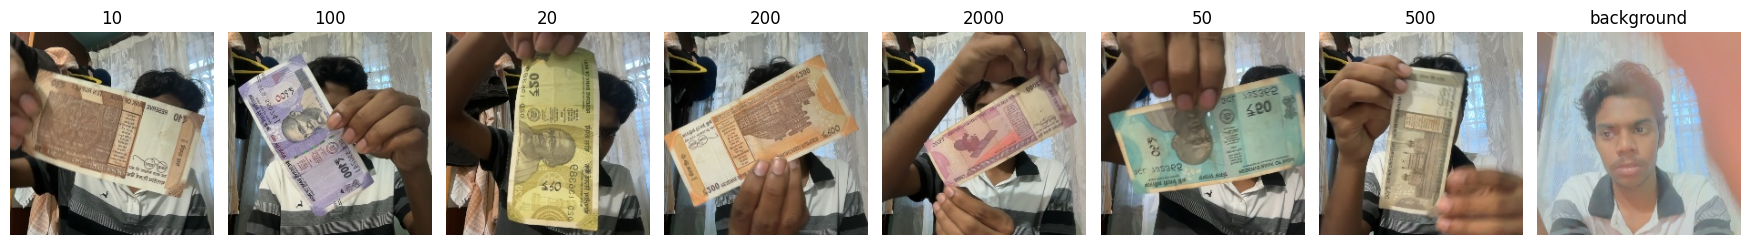

In [3]:
# Preview a sample from each class
fig, axes = plt.subplots(1, len(classes), figsize=(2.2*len(classes), 2.4))
if len(classes) == 1: axes = [axes]
for ax, c in zip(axes, classes):
    files = glob.glob(os.path.join(DATASET_DIR, c, '*.*'))
    if not files:
        ax.set_title(f'{c}\n(empty)'); ax.axis('off'); continue
    img = tf.keras.utils.load_img(random.choice(files), target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img); ax.set_title(c); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. Build train/val datasets with augmentation

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset='training', seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, label_mode='int')
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset='validation', seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, label_mode='int')

class_names = train_ds.class_names
print('class_names:', class_names)
num_classes = len(class_names)

# Compute class weights to handle imbalance (e.g. fewer background images)
from collections import Counter
counts_all = {c: len(glob.glob(os.path.join(DATASET_DIR, c, '*.*'))) for c in class_names}
total_imgs = sum(counts_all.values())
class_weight = {i: total_imgs / (len(class_names) * counts_all[c]) for i, c in enumerate(class_names)}
print('class_weight:', {class_names[i]: round(w, 2) for i, w in class_weight.items()})

AUTOTUNE = tf.data.AUTOTUNE
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.25),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
], name='augment')

def prep(ds, training=False):
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_p = prep(train_ds, training=True)
val_p = prep(val_ds)

Found 874 files belonging to 8 classes.
Using 700 files for training.
Found 874 files belonging to 8 classes.
Using 174 files for validation.
class_names: ['10', '100', '20', '200', '2000', '50', '500', 'background']


## 3. Build model — MobileNetV2 transfer learning

In [ ]:
base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs, name='VisionPay_MobileNetV2')

model.compile(optimizer=optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "VisionPay_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Train head

In [ ]:
cbs = [
    callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss'),
]
h1 = model.fit(train_p, validation_data=val_p, epochs=EPOCHS_HEAD,
               class_weight=class_weight, callbacks=cbs)

Epoch 1/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.3257 - loss: 1.8345 - val_accuracy: 0.7069 - val_loss: 1.1399 - learning_rate: 0.0010
Epoch 2/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.6614 - loss: 0.9850 - val_accuracy: 0.8391 - val_loss: 0.6331 - learning_rate: 0.0010
Epoch 3/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.8086 - loss: 0.6138 - val_accuracy: 0.8563 - val_loss: 0.5618 - learning_rate: 0.0010
Epoch 4/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8900 - loss: 0.4038 - val_accuracy: 0.8851 - val_loss: 0.3996 - learning_rate: 0.0010
Epoch 5/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.9043 - loss: 0.2930 - val_accuracy: 0.9195 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 6/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.9214 - loss: 0.2711 - val_accuracy: 0.8276 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 7/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.9429 - loss: 0.2180 - 

## 5. Fine-tune top layers

In [ ]:
base.trainable = True
# Unfreeze last 60 layers for deeper fine-tuning
for l in base.layers[:-60]:
    l.trainable = False

model.compile(optimizer=optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = model.fit(train_p, validation_data=val_p, epochs=EPOCHS_FINETUNE,
               class_weight=class_weight, callbacks=cbs)

Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.6857 - loss: 0.9449 - val_accuracy: 0.9253 - val_loss: 0.2990 - learning_rate: 1.0000e-05
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.7871 - loss: 0.6673 - val_accuracy: 0.9253 - val_loss: 0.2911 - learning_rate: 1.0000e-05
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.8314 - loss: 0.5396 - val_accuracy: 0.9195 - val_loss: 0.2897 - learning_rate: 5.0000e-06
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.8886 - loss: 0.4209 - val_accuracy: 0.9195 - val_loss: 0.2873 - learning_rate: 5.0000e-06


## 6. Evaluate

              precision    recall  f1-score   support

          10       1.00      0.81      0.90        32
         100       0.81      1.00      0.89        25
          20       0.90      1.00      0.95        19
         200       0.95      1.00      0.98        20
        2000       1.00      0.86      0.92        21
          50       0.90      0.90      0.90        21
         500       0.92      0.96      0.94        24
  background       1.00      0.92      0.96        12

    accuracy                           0.93       174
   macro avg       0.94      0.93      0.93       174
weighted avg       0.93      0.93      0.93       174



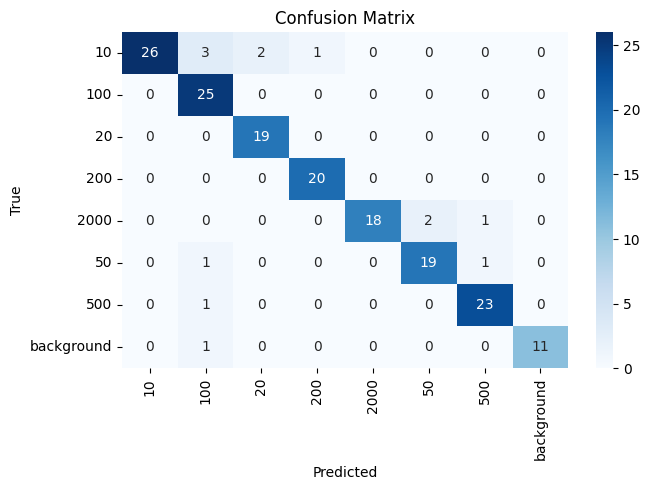

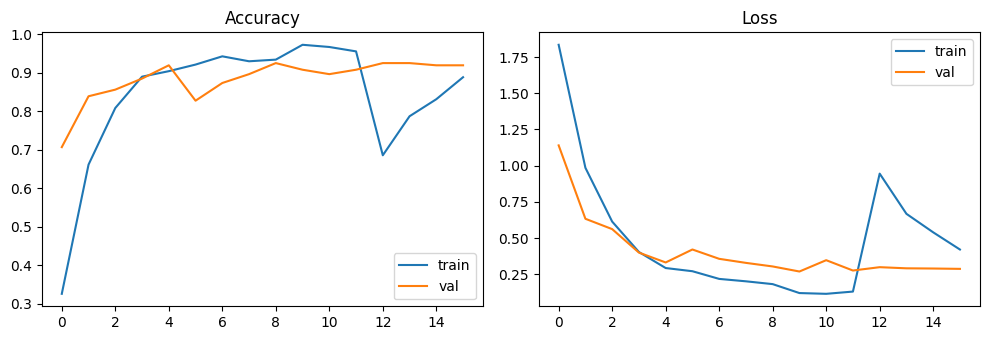

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for x, y in val_p:
    p = model.predict(x, verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(p, axis=1).tolist())

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()

# Plot training curves
def merge(a, b, key): return list(a.history[key]) + list(b.history[key])
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.plot(merge(h1, h2, 'accuracy'), label='train')
plt.plot(merge(h1, h2, 'val_accuracy'), label='val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(merge(h1, h2, 'loss'), label='train')
plt.plot(merge(h1, h2, 'val_loss'), label='val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

## 7. Save model for the Flask app

In [ ]:
model.save(os.path.join(MODEL_DIR, 'visionpay_model.keras'))
with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w') as f:
    json.dump(class_names, f)
print('Saved keras model to', MODEL_DIR)

# Convert to TFLite (quantized) for 3-4x faster inference
print('Converting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path = os.path.join(MODEL_DIR, 'visionpay_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'Saved TFLite model: {tflite_path} ({len(tflite_model)/1e6:.1f} MB)')

Saved to model


## 8. Quick inference test

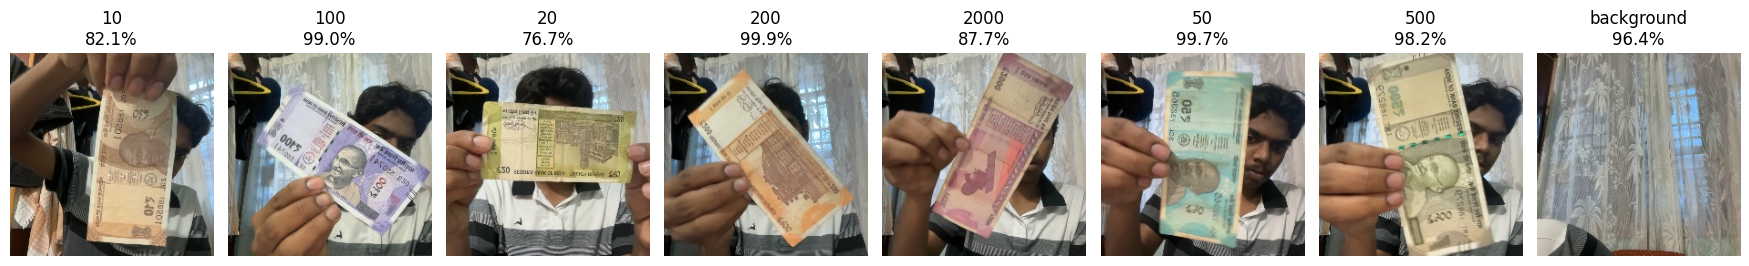

In [10]:
def predict_path(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = preprocess_input(np.expand_dims(tf.keras.utils.img_to_array(img), 0))
    p = model.predict(arr, verbose=0)[0]
    i = int(np.argmax(p))
    return class_names[i], float(p[i])

samples = []
for c in class_names:
    fs = glob.glob(os.path.join(DATASET_DIR, c, '*.*'))
    if fs: samples.append(random.choice(fs))

fig, axes = plt.subplots(1, len(samples), figsize=(2.2*len(samples), 2.6))
if len(samples) == 1: axes = [axes]
for ax, s in zip(axes, samples):
    label, conf = predict_path(s)
    img = tf.keras.utils.load_img(s, target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{label}\n{conf*100:.1f}%')
plt.tight_layout(); plt.show()

## Done — now run the web app
```bash
python app.py
# open http://localhost:5050
```

In [11]:
python app.py

SyntaxError: invalid syntax (945115591.py, line 1)